In [23]:
from google.colab import drive
drive.mount('/content/drive/')

import pandas as pd
url = 'https://raw.githubusercontent.com/aadimangla/Restaurant-Reviews-Sentiment-Analysis/master/Dataset/Restaurant_Reviews.tsv'
data = pd.read_csv(url, delimiter='\t', quoting=3)

# Save a copy into your Drive
data.to_csv('/content/drive/MyDrive/Restaurant_Reviews.tsv', sep='\t', index=False, quoting=3)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [24]:
data = pd.read_csv('/content/drive/MyDrive/Restaurant_Reviews.tsv', delimiter='\t', quoting=3)


In [25]:
import numpy as np
import pandas as pd


In [26]:
data = pd.read_csv('/content/drive/MyDrive/Restaurant_Reviews.tsv', delimiter='\t', quoting=3)

print(data.shape)      # (1000, 2) -> 1000 reviews, 2 columns
print(data.columns)    # Index(['Review', 'Liked'], dtype='object')
data.head()
data.info

(1000, 2)
Index(['Review', 'Liked'], dtype='object')


<bound method DataFrame.info of                                                 Review  Liked
0                             Wow... Loved this place.      1
1                                   Crust is not good.      0
2            Not tasty and the texture was just nasty.      0
3    Stopped by during the late May bank holiday of...      1
4    The selection on the menu was great and so wer...      1
..                                                 ...    ...
995  I think food should have flavor and texture an...      0
996                           Appetite instantly gone.      0
997  Overall I was not impressed and would not go b...      0
998  The whole experience was underwhelming, and I ...      0
999  Then, as if I hadn't wasted enough of my life ...      0

[1000 rows x 2 columns]>

In [27]:
import nltk
import re
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [28]:
corpus = []
for i in range(0, 1000):
    review = re.sub(pattern='[^a-zA-Z]', repl=' ', string=data['Review'][i])
    review = review.lower()
    review_words = review.split()
    review_words = [word for word in review_words if not word in set(stopwords.words('english'))]

    ps = PorterStemmer()
    review = [ps.stem(word) for word in review_words]

    review = ' '.join(review)
    corpus.append(review)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = data.iloc[:, 1].values

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(800, 1500) (200, 1500) (800,) (200,)


In [31]:
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

In [32]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 1])

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred)   # fixed from accuracy_score
score3 = recall_score(y_test, y_pred)

print("---------SCORES--------")
print("Accuracy score is {}%".format(round(score1*100, 3)))
print("Precision score is {}%".format(round(score2*100, 3)))
print("Recall score is {}%".format(round(score3*100, 3)))

---------SCORES--------
Accuracy score is 76.5%
Precision score is 76.415%
Recall score is 78.641%


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[72, 25],
       [22, 81]])

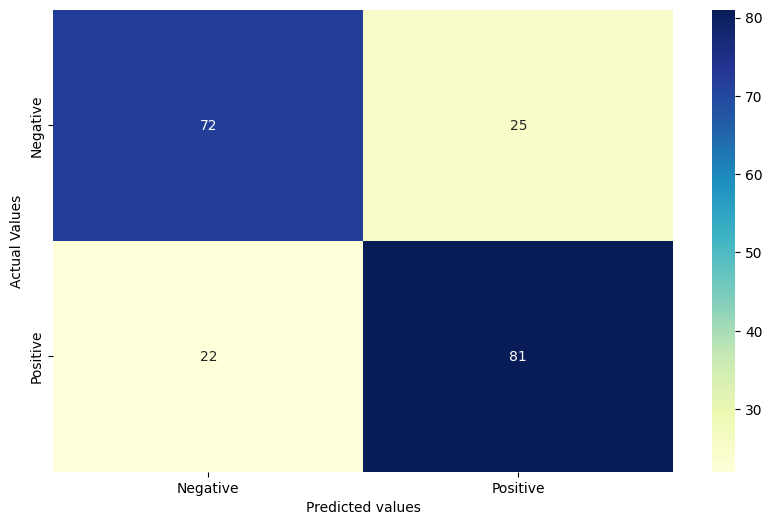

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, cmap="YlGnBu",
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted values')
plt.ylabel('Actual Values')
plt.show()

In [36]:
best_accuracy = 0.0
alpha_val = 0.0

for i in np.arange(0.1, 1.1, 0.1):
    temp_classifier = MultinomialNB(alpha=i)
    temp_classifier.fit(X_train, y_train)
    temp_y_pred = temp_classifier.predict(X_test)
    score = accuracy_score(y_test, temp_y_pred)
    print("Accuracy Score for alpha={} is {}%".format(round(i, 1), round(score*100, 3)))
    if score > best_accuracy:
        best_accuracy = score
        alpha_val = i

print('----------------------------------------------------')
print("The Best Accuracy Score is {}% with alpha value as {}".format(round(best_accuracy*100, 2), round(alpha_val, 1)))

Accuracy Score for alpha=0.1 is 78.0%
Accuracy Score for alpha=0.2 is 78.5%
Accuracy Score for alpha=0.3 is 78.0%
Accuracy Score for alpha=0.4 is 78.5%
Accuracy Score for alpha=0.5 is 77.5%
Accuracy Score for alpha=0.6 is 77.5%
Accuracy Score for alpha=0.7 is 77.5%
Accuracy Score for alpha=0.8 is 77.0%
Accuracy Score for alpha=0.9 is 76.5%
Accuracy Score for alpha=1.0 is 76.5%
----------------------------------------------------
The Best Accuracy Score is 78.5% with alpha value as 0.2


In [37]:
classifier = MultinomialNB(alpha=alpha_val)   # use the best value found above
classifier.fit(X_train, y_train)

MultinomialNB(alpha=np.float64(0.2))

In [38]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def predict_sentiment(sample_review):
    sample_review = re.sub(pattern='[^a-zA-Z]', repl=' ', string=sample_review)
    sample_review = sample_review.lower()
    sample_review_words = sample_review.split()
    sample_review_words = [word for word in sample_review_words if not word in set(stopwords.words('english'))]
    ps = PorterStemmer()
    final_review = [ps.stem(word) for word in sample_review_words]
    final_review = ' '.join(final_review)

    temp = cv.transform([final_review]).toarray()
    return classifier.predict(temp)

In [39]:
sample_review = 'The food is really bad.'
if predict_sentiment(sample_review):
    print("Positive review")
else:
    print("Negative review")



Negative review


In [40]:
sample_review = 'Food was pretty bad and the service was very slow'
if predict_sentiment(sample_review):
    print("Positive review")
else:
    print("Negative review")

Negative review


In [41]:
sample_review = 'The food was absolutely wonderful, from preparation to presentation, very pleasing.'
if predict_sentiment(sample_review):
    print("This is a Positive review")
else:
    print("This is a Negative review")

This is a Positive review


In [42]:
sample_review = 'food averag'
if predict_sentiment(sample_review):
    print("This is a Positive review")
else:
    print("This is a Negative review")

This is a Negative review
